In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from sklearn.utils.class_weight import compute_class_weight

In [2]:
from tensorflow.keras import layers
from tensorflow.keras.models import Model
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.callbacks import (
    ModelCheckpoint,
    EarlyStopping,
    ReduceLROnPlateau
)

In [3]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [18]:
IMAGE_SIZE = (224, 224)

BATCH_SIZE = 16

NUM_CLASSES = 6

EPOCHS_FINE = 20

DATA_DIR = "../datasets/sampled_sneakers_1024x1024"

TRAIN_CSV = "../datasets/splits/train_images.csv"
VAL_CSV = "../datasets/splits/val_images.csv"
TEST_CSV = "../datasets/splits/test_images.csv"

MODEL_PATH = "../models/brand_classifier_resnet50.keras"

In [5]:
train_df = pd.read_csv(
    TRAIN_CSV
)

val_df = pd.read_csv(
    VAL_CSV
)

test_df = pd.read_csv(
    TEST_CSV
)

print(
    "Train:",
    len(train_df)
)

print(
    "Validation:",
    len(val_df)
)

print(
    "Test:",
    len(test_df)
)

Train: 1848
Validation: 397
Test: 397


In [6]:
print("TRAIN")
print(
    train_df["brand"].value_counts()
)

print("\nVALIDATION")
print(
    val_df["brand"].value_counts()
)

print("\nTEST")
print(
    test_df["brand"].value_counts()
)

TRAIN
brand
vans           643
puma           383
nike           265
reebok         239
underarmour    160
newbalance     158
Name: count, dtype: int64

VALIDATION
brand
vans           138
puma            82
nike            57
reebok          51
underarmour     35
newbalance      34
Name: count, dtype: int64

TEST
brand
vans           138
puma            82
nike            57
reebok          51
underarmour     35
newbalance      34
Name: count, dtype: int64


In [7]:
brands = sorted(
    train_df["brand"].unique()
)

brand_to_id = {
    brand: i
    for i, brand in enumerate(brands)
}

id_to_brand = {
    i: brand
    for brand, i in brand_to_id.items()
}

print(
    brand_to_id
)

{'newbalance': 0, 'nike': 1, 'puma': 2, 'reebok': 3, 'underarmour': 4, 'vans': 5}


In [8]:
train_df["label"] = train_df[
    "brand"
].map(
    brand_to_id
)

val_df["label"] = val_df[
    "brand"
].map(
    brand_to_id
)

test_df["label"] = test_df[
    "brand"
].map(
    brand_to_id
)

In [9]:
def get_image_path(filename):
    return os.path.join(
        DATA_DIR,
        filename
    )


for df in [
    train_df,
    val_df,
    test_df
]:

    df["image_path"] = df[
        "image_name"
    ].apply(
        get_image_path
    )


print(
    train_df["image_path"].iloc[0]
)

../datasets/sampled_sneakers_1024x1024\resized_padded_vans_167.jpg


In [10]:
for name, df in [
    ("Train", train_df),
    ("Validation", val_df),
    ("Test", test_df)
]:

    missing = [
        p
        for p in df["image_path"]
        if not os.path.exists(p)
    ]

    print(
        name,
        "missing:",
        len(missing)
    )

Train missing: 0
Validation missing: 0
Test missing: 0


In [11]:
classes = np.array(
    sorted(
        train_df["label"].unique()
    )
)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_df["label"]
)

class_weights = {
    int(cls): float(weight)
    for cls, weight in zip(
        classes,
        weights
    )
}

print(
    class_weights
)

{0: 1.9493670886075949, 1: 1.1622641509433962, 2: 0.804177545691906, 3: 1.288702928870293, 4: 1.925, 5: 0.47900466562986005}


In [12]:
def make_dataset(
    df,
    training=False
):

    paths = df[
        "image_path"
    ].values

    labels = df[
        "label"
    ].values

    ds = tf.data.Dataset.from_tensor_slices(
        (
            paths,
            labels
        )
    )

    if training:

        ds = ds.shuffle(
            len(df),
            seed=SEED
        )

    def load_image(
        path,
        label
    ):

        image = tf.io.read_file(
            path
        )

        image = tf.image.decode_jpeg(
            image,
            channels=3
        )

        image = tf.image.resize(
            image,
            IMAGE_SIZE
        )

        image = tf.cast(
            image,
            tf.float32
        )

        image = preprocess_input(
            image
        )

        return image, label

    ds = ds.map(
        load_image,
        num_parallel_calls=tf.data.AUTOTUNE
    )

    ds = ds.batch(
        BATCH_SIZE
    )

    ds = ds.prefetch(
        tf.data.AUTOTUNE
    )

    return ds

In [13]:
train_ds = make_dataset(
    train_df,
    training=True
)

val_ds = make_dataset(
    val_df,
    training=False
)

test_ds = make_dataset(
    test_df,
    training=False
)

In [14]:
base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(
        224,
        224,
        3
    )
)

base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

for layer in base_model.layers[-30:]:
    layer.trainable = True

In [15]:
inputs = layers.Input(
    shape=(
        224,
        224,
        3
    )
)

x = base_model(
    inputs,
    training=False
)

x = layers.GlobalAveragePooling2D()(
    x
)

x = layers.Dense(
    256,
    activation="relu"
)(
    x
)

x = layers.Dropout(
    0.4
)(
    x
)

outputs = layers.Dense(
    NUM_CLASSES,
    activation="softmax"
)(
    x
)

classifier = Model(
    inputs,
    outputs,
    name="ResNet50_BrandClassifier"
)

classifier.summary()

Model: "ResNet50_BrandClassifier"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 resnet50 (Functional)       (None, 7, 7, 2048)        23587712  
                                                                 
 global_average_pooling2d (G  (None, 2048)             0         
 lobalAveragePooling2D)                                          
                                                                 
 dense (Dense)               (None, 256)               524544    
                                                                 
 dropout (Dropout)           (None, 256)               0         
                                                                 
 dense_1 (Dense)             (None, 6)                 1542      
                                          

In [16]:
classifier.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-5
    ),

    loss="sparse_categorical_crossentropy",

    metrics=[
        "accuracy"
    ]
)

In [17]:
checkpoint = ModelCheckpoint(
    MODEL_PATH,
    monitor="val_loss",
    save_best_only=True,
    mode="min",
    verbose=1
)

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
    mode="min",
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

In [19]:
history_fine = classifier.fit(
    train_ds,

    validation_data=val_ds,

    epochs=EPOCHS_FINE,

    class_weight=class_weights,

    callbacks=[
        checkpoint,
        early_stopping,
        reduce_lr
    ]
)

Epoch 1/20
116/116 [==============================] - ETA: 0s - loss: 1.6749 - accuracy: 0.3128
Epoch 1: val_loss improved from inf to 1.23749, saving model to ../models\brand_classifier_resnet50.keras
116/116 [==============================] - 20s 102ms/step - loss: 1.6749 - accuracy: 0.3128 - val_loss: 1.2375 - val_accuracy: 0.5819 - lr: 1.0000e-05
Epoch 2/20
115/116 [============================>.] - ETA: 0s - loss: 0.9556 - accuracy: 0.6250
Epoch 2: val_loss improved from 1.23749 to 0.65705, saving model to ../models\brand_classifier_resnet50.keras
116/116 [==============================] - 11s 91ms/step - loss: 0.9551 - accuracy: 0.6255 - val_loss: 0.6570 - val_accuracy: 0.7733 - lr: 1.0000e-05
Epoch 3/20
115/116 [============================>.] - ETA: 0s - loss: 0.5220 - accuracy: 0.8000
Epoch 3: val_loss improved from 0.65705 to 0.56806, saving model to ../models\brand_classifier_resnet50.keras
116/116 [==============================] - 11s 96ms/step - loss: 0.5244 - accuracy: 0

In [20]:
test_loss, test_accuracy = (
    classifier.evaluate(
        test_ds,
        verbose=1
    )
)

print(
    "Test Accuracy:",
    round(
        test_accuracy,
        4
    )
)

25/25 [==============================] - 1s 57ms/step - loss: 0.3893 - accuracy: 0.8866
Test Accuracy: 0.8866


In [21]:
y_true = []
y_pred = []

for images, labels in test_ds:

    probs = classifier.predict(
        images,
        verbose=0
    )

    preds = np.argmax(
        probs,
        axis=1
    )

    y_true.extend(
        labels.numpy()
    )

    y_pred.extend(
        preds
    )

y_true = np.array(
    y_true
)

y_pred = np.array(
    y_pred
)

In [22]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=[
            id_to_brand[i]
            for i in range(NUM_CLASSES)
        ],
        digits=4
    )
)

              precision    recall  f1-score   support

  newbalance     0.8333    0.8824    0.8571        34
        nike     0.9180    0.9825    0.9492        57
        puma     0.8312    0.7805    0.8050        82
      reebok     0.7800    0.7647    0.7723        51
 underarmour     0.8750    1.0000    0.9333        35
        vans     0.9624    0.9275    0.9446       138

    accuracy                         0.8866       397
   macro avg     0.8667    0.8896    0.8769       397
weighted avg     0.8867    0.8866    0.8858       397



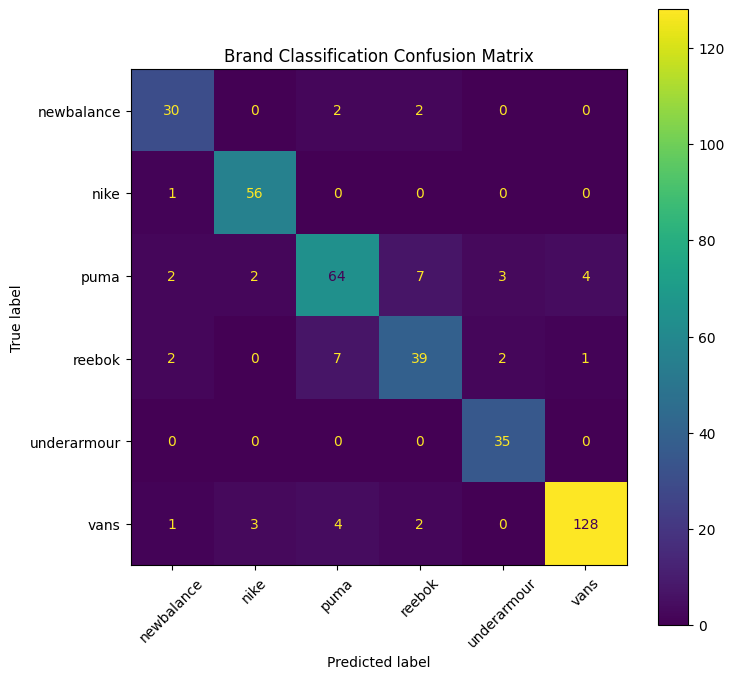

In [23]:
cm = confusion_matrix(
    y_true,
    y_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,

    display_labels=[
        id_to_brand[i]
        for i in range(NUM_CLASSES)
    ]
)

fig, ax = plt.subplots(
    figsize=(8, 8)
)

disp.plot(
    ax=ax,
    xticks_rotation=45
)

plt.title(
    "Brand Classification Confusion Matrix"
)

plt.show()

In [24]:
FINAL_MODEL_PATH = (
    "../models/brand_classifier_resnet50.keras"
)

classifier.save(
    FINAL_MODEL_PATH
)

print(
    "Saved:",
    FINAL_MODEL_PATH
)

Saved: ../models/brand_classifier_resnet50.keras
